In [1]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("processed_insurance.csv")

In [3]:
X = df.drop("insuranceclaim", axis=1)

y = df["insuranceclaim"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [5]:
best_model = joblib.load("best_model.pkl")

print(best_model)

GradientBoostingClassifier(max_depth=5)


In [6]:
y_pred = best_model.predict(X_test)

In [7]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[104   3]
 [  3 158]]


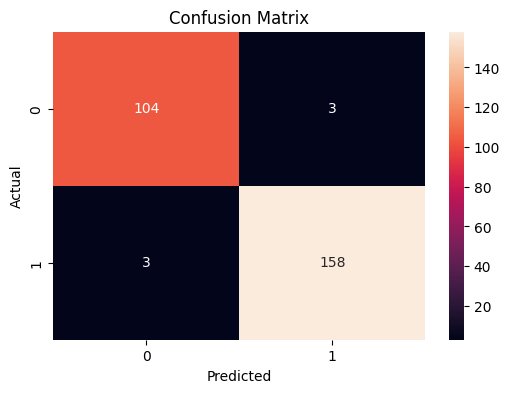

In [8]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [9]:
print(
    classification_report(
        y_test,
        y_pred
    )
)


              precision    recall  f1-score   support

           0       0.97      0.97      0.97       107
           1       0.98      0.98      0.98       161

    accuracy                           0.98       268
   macro avg       0.98      0.98      0.98       268
weighted avg       0.98      0.98      0.98       268



In [10]:
TN, FP, FN, TP = cm.ravel()

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("Specificity :", TN/(TN+FP))
print("FPR :", FP/(FP+TN))
print("FNR :", FN/(FN+TP))
print("NPV :", TN/(TN+FN))

Accuracy : 0.9776119402985075
Precision : 0.9813664596273292
Recall : 0.9813664596273292
F1 Score : 0.9813664596273292
Specificity : 0.9719626168224299
FPR : 0.028037383177570093
FNR : 0.018633540372670808
NPV : 0.9719626168224299


In [11]:
y_prob = best_model.predict_proba(X_test)[:,1]

auc = roc_auc_score(
    y_test,
    y_prob
)

print("AUC Score :", auc)

AUC Score : 0.9950658849480467


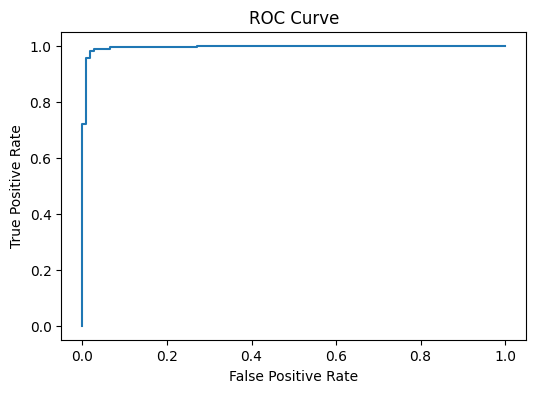

In [12]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

In [13]:
print(X.columns.tolist())

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'BMI_Age', 'Family_Size']


In [14]:
print(f"Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred)*100:.2f}%")
print(f"Recall : {recall_score(y_test, y_pred)*100:.2f}%")
print(f"F1 Score : {f1_score(y_test, y_pred)*100:.2f}%")

print(f"Specificity : {(TN/(TN+FP))*100:.2f}%")
print(f"FPR : {(FP/(FP+TN))*100:.2f}%")
print(f"FNR : {(FN/(FN+TP))*100:.2f}%")
print(f"NPV : {(TN/(TN+FN))*100:.2f}%")

Accuracy : 97.76%
Precision : 98.14%
Recall : 98.14%
F1 Score : 98.14%
Specificity : 97.20%
FPR : 2.80%
FNR : 1.86%
NPV : 97.20%


In [15]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

import pandas as pd

report_df = pd.DataFrame(report).transpose()

report_df.iloc[:, :3] = report_df.iloc[:, :3] * 100

report_df

,precision,recall,f1-score,support
0,97.196262,97.196262,97.196262,107.000000
1,98.136646,98.136646,98.136646,161.000000
accuracy,97.761194,97.761194,97.761194,0.977612
macro avg,97.666454,97.666454,97.666454,268.000000
weighted avg,97.761194,97.761194,97.761194,268.000000
